In [103]:
import os
import json
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

import torch
import torchvision

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

import warnings
warnings.filterwarnings("ignore")

In [104]:
SEED = 42
IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = os.cpu_count()

BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "data"

REAL_DIR = DATA_DIR / "real"
FAKE_DIR = DATA_DIR / "fake"

MODEL_DIR = BASE_DIR.parent.parent / "models" / "currency"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print("Device :", DEVICE)
print("Dataset:", DATA_DIR)
print("Model :", MODEL_DIR)

Device : cuda
Dataset: c:\Users\ANKIT\Desktop\SentinelAi\datasets\currency\data
Model : c:\Users\ANKIT\Desktop\SentinelAi\models\currency


In [105]:
def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)

In [106]:
assert DATA_DIR.exists(), "Dataset folder not found."

assert REAL_DIR.exists(), "Real folder missing."

assert FAKE_DIR.exists(), "Fake folder missing."

print("Dataset verified successfully.")

Dataset verified successfully.


In [107]:
for cls in ["real", "fake"]:

    print(f"\n{cls.upper()}")

    folders = sorted(os.listdir(DATA_DIR / cls), key=lambda x: int(x))

    for folder in folders:
        print("  ├──", folder)


REAL
  ├── 10
  ├── 20
  ├── 50
  ├── 100
  ├── 200
  ├── 500
  ├── 2000

FAKE
  ├── 10
  ├── 20
  ├── 50
  ├── 100
  ├── 200
  ├── 500
  ├── 2000


In [108]:
extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

summary = []

for cls in ["real", "fake"]:

    class_path = DATA_DIR / cls

    for denomination in sorted(os.listdir(class_path), key=int):

        folder = class_path / denomination

        count = len(
            [
                f
                for f in folder.iterdir()
                if f.suffix.lower() in extensions
            ]
        )

        summary.append(
            {
                "Class": cls,
                "Denomination": denomination,
                "Images": count,
            }
        )

df_summary = pd.DataFrame(summary)

df_summary

,Class,Denomination,Images
0,real,10,950
1,real,20,948
2,real,50,844
3,real,100,726
4,real,200,563
5,real,500,649
6,real,2000,257
7,fake,10,300
8,fake,20,299
9,fake,50,299


In [109]:
print("Total Images :", df_summary["Images"].sum())

print()

print(df_summary.groupby("Class")["Images"].sum())

print()

print(df_summary)

Total Images : 7443

Class
fake    2506
real    4937
Name: Images, dtype: int64

   Class Denomination  Images
0   real           10     950
1   real           20     948
2   real           50     844
3   real          100     726
4   real          200     563
5   real          500     649
6   real         2000     257
7   fake           10     300
8   fake           20     299
9   fake           50     299
10  fake          100     380
11  fake          200     278
12  fake          500     805
13  fake         2000     145


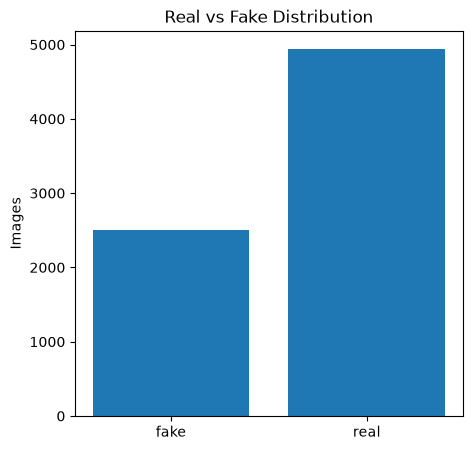

In [110]:
class_counts = df_summary.groupby("Class")["Images"].sum()

plt.figure(figsize=(5,5))

plt.bar(class_counts.index, class_counts.values)

plt.title("Real vs Fake Distribution")

plt.ylabel("Images")

plt.show()

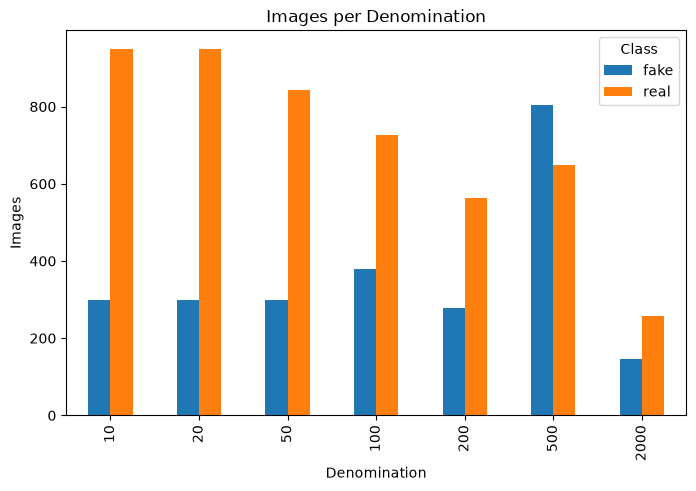

In [111]:
pivot = (
    df_summary
    .assign(Denomination=df_summary["Denomination"].astype(int))
    .pivot(index="Denomination", columns="Class", values="Images")
    .sort_index()
)

pivot.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Images")
plt.title("Images per Denomination")

plt.show()

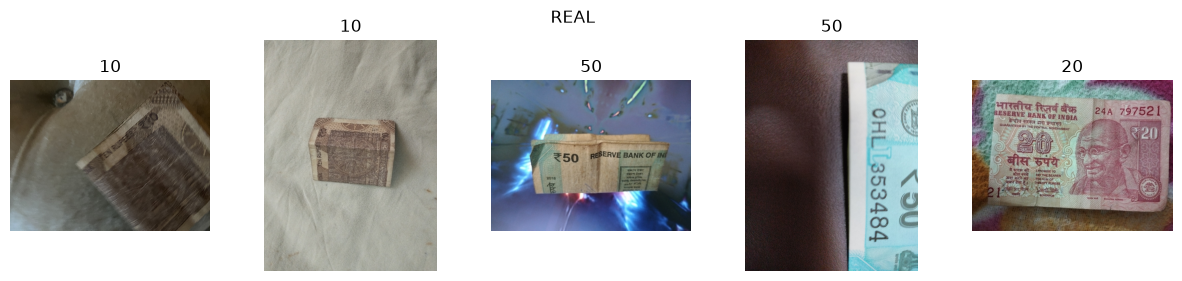

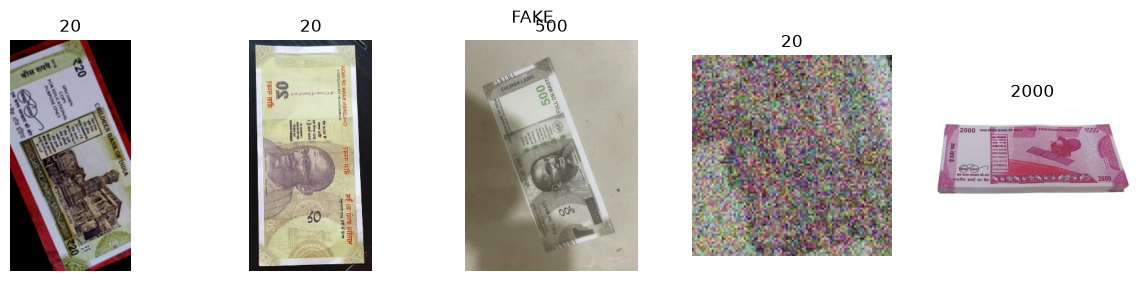

In [112]:
import random

def show_samples(class_name, n=5):
    class_dir = DATA_DIR / class_name

    image_paths = []

    for denomination in sorted(os.listdir(class_dir), key=int):
        folder = class_dir / denomination

        files = [
            f for f in folder.iterdir()
            if f.suffix.lower() in (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        ]

        image_paths.extend(files)

    samples = random.sample(image_paths, n)

    plt.figure(figsize=(15, 3))

    for i, img_path in enumerate(samples):

        img = Image.open(img_path)

        plt.subplot(1, n, i + 1)

        plt.imshow(img)

        plt.title(img_path.parent.name)

        plt.axis("off")

    plt.suptitle(class_name.upper())

    plt.show()


show_samples("real")

show_samples("fake")

In [113]:
from collections import Counter

resolutions = []

for cls in ["real", "fake"]:

    class_dir = DATA_DIR / cls

    for denomination in sorted(os.listdir(class_dir), key=int):

        folder = class_dir / denomination

        for img_path in folder.iterdir():

            if img_path.suffix.lower() not in (".jpg", ".jpeg", ".png", ".bmp", ".webp"):
                continue

            try:
                img = Image.open(img_path)

                resolutions.append(img.size)

            except:
                pass

resolution_df = pd.DataFrame(
    resolutions,
    columns=["Width", "Height"]
)

resolution_df.head()

,Width,Height
0,482,280
1,626,197
2,1300,956
3,1600,747
4,1300,956


In [114]:
print(resolution_df.describe())

             Width       Height
count  7443.000000  7443.000000
mean   1216.082897  1165.388419
std    1503.034552  1518.042523
min     100.000000    82.000000
25%     224.000000   379.000000
50%     640.000000   480.000000
75%     960.000000   720.000000
max    9248.000000  9248.000000


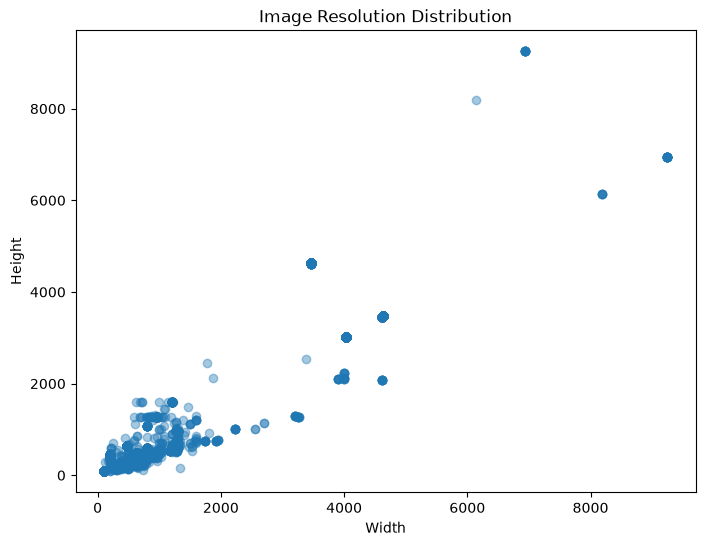

In [115]:
plt.figure(figsize=(8,6))

plt.scatter(
    resolution_df["Width"],
    resolution_df["Height"],
    alpha=0.4
)

plt.xlabel("Width")

plt.ylabel("Height")

plt.title("Image Resolution Distribution")

plt.show()

In [116]:
Counter(resolutions).most_common(15)

[((640, 480), 2061),
 ((100, 100), 783),
 ((3468, 4624), 716),
 ((480, 640), 614),
 ((4624, 3468), 361),
 ((224, 224), 259),
 ((4032, 3024), 228),
 ((4608, 3456), 121),
 ((800, 600), 72),
 ((1200, 1600), 64),
 ((960, 1280), 62),
 ((200, 387), 51),
 ((200, 385), 44),
 ((200, 386), 44),
 ((200, 397), 44)]

In [117]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

all_image_paths = []

for cls in ["real", "fake"]:
    class_dir = DATA_DIR / cls

    for denom_dir in sorted(class_dir.iterdir(), key=lambda x: int(x.name)):
        if not denom_dir.is_dir():
            continue

        for img_path in denom_dir.iterdir():
            if (
                img_path.is_file()
                and img_path.suffix.lower() in IMAGE_EXTENSIONS
            ):
                all_image_paths.append(img_path)

print(f"Total image files found: {len(all_image_paths):,}")

Total image files found: 7,443


,Format,Count
0,.jpg,5403
1,.jpeg,1924
2,.png,115
3,.webp,1


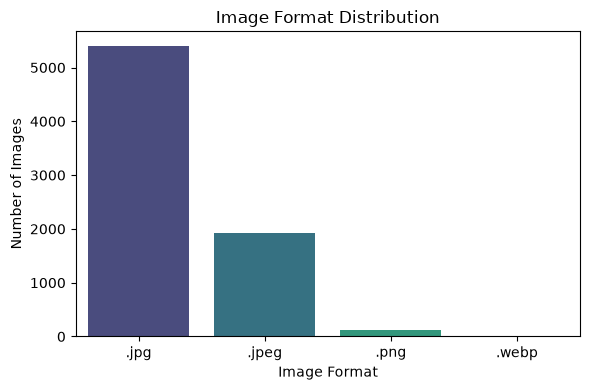

In [118]:
from collections import Counter

image_formats = Counter()

for img_path in all_image_paths:
    image_formats[img_path.suffix.lower()] += 1

format_df = (
    pd.DataFrame(
        image_formats.items(),
        columns=["Format", "Count"]
    )
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

display(format_df)

plt.figure(figsize=(6,4))

sns.barplot(
    data=format_df,
    x="Format",
    y="Count",
    hue="Format",
    palette="viridis",
    legend=False
)

plt.title("Image Format Distribution")
plt.xlabel("Image Format")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

In [119]:
from PIL import Image

corrupted_images = []

for img_path in tqdm(all_image_paths, desc="Checking Images"):
    try:
        with Image.open(img_path) as img:
            img.verify()
    except Exception:
        corrupted_images.append(img_path)

print(f"Total Corrupted Images: {len(corrupted_images)}")

if corrupted_images:
    corrupted_df = pd.DataFrame(
        corrupted_images,
        columns=["Corrupted Image"]
    )
    display(corrupted_df.head())
else:
    print("No corrupted images found.")

Checking Images:   0%|          | 0/7443 [00:00<?, ?it/s]

Total Corrupted Images: 0
No corrupted images found.


In [120]:
import hashlib

hash_dict = {}
duplicate_pairs = []

for img_path in tqdm(all_image_paths, desc="Checking Exact Duplicates"):
    try:
        with open(img_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        if file_hash in hash_dict:
            duplicate_pairs.append((hash_dict[file_hash], img_path))
        else:
            hash_dict[file_hash] = img_path

    except Exception:
        continue

print(f"Exact Duplicate Pairs Found: {len(duplicate_pairs)}")

duplicate_df = pd.DataFrame(
    duplicate_pairs,
    columns=["Original Image", "Duplicate Image"]
)

display(duplicate_df.head())

Checking Exact Duplicates:   0%|          | 0/7443 [00:00<?, ?it/s]

Exact Duplicate Pairs Found: 275


,Original Image,Duplicate Image
0,c:\Users\ANKIT\Desktop\SentinelAi\datasets\cur...,c:\Users\ANKIT\Desktop\SentinelAi\datasets\cur...
1,c:\Users\ANKIT\Desktop\SentinelAi\datasets\cur...,c:\Users\ANKIT\Desktop\SentinelAi\datasets\cur...
2,c:\Users\ANKIT\Desktop\SentinelAi\datasets\cur...,c:\Users\ANKIT\Desktop\SentinelAi\datasets\cur...
3,c:\Users\ANKIT\Desktop\SentinelAi\datasets\cur...,c:\Users\ANKIT\Desktop\SentinelAi\datasets\cur...
4,c:\Users\ANKIT\Desktop\SentinelAi\datasets\cur...,c:\Users\ANKIT\Desktop\SentinelAi\datasets\cur...


Computing Aspect Ratios:   0%|          | 0/7443 [00:00<?, ?it/s]

       Aspect Ratio
count   7443.000000
mean       1.157877
std        0.487019
min        0.348915
25%        0.750000
50%        1.333333
75%        1.333333
max        8.417722


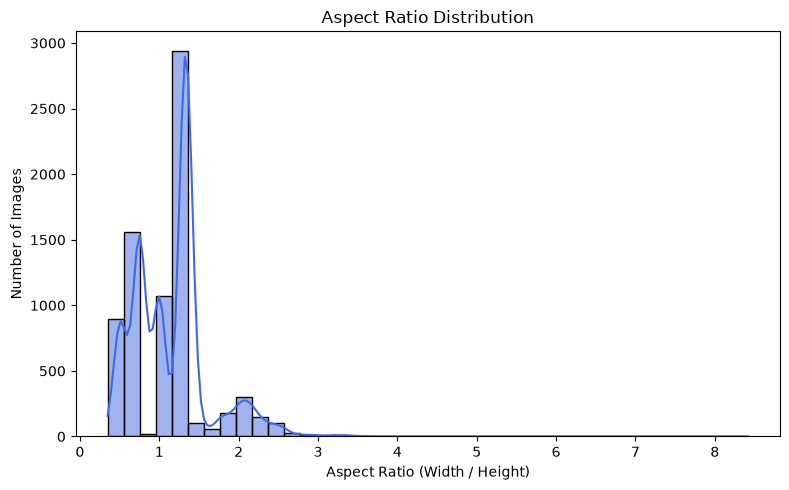

In [121]:
aspect_ratios = []

for img_path in tqdm(all_image_paths, desc="Computing Aspect Ratios"):
    try:
        with Image.open(img_path) as img:
            width, height = img.size

        aspect_ratios.append(width / height)

    except Exception:
        continue

aspect_df = pd.DataFrame(
    aspect_ratios,
    columns=["Aspect Ratio"]
)

print(aspect_df.describe())

plt.figure(figsize=(8,5))

sns.histplot(
    aspect_df["Aspect Ratio"],
    bins=40,
    kde=True,
    color="royalblue"
)

plt.title("Aspect Ratio Distribution")
plt.xlabel("Aspect Ratio (Width / Height)")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

In [122]:

channel_sum = np.zeros(3)
channel_squared_sum = np.zeros(3)
total_pixels = 0

for img_path in tqdm(all_image_paths, desc="RGB Statistics"):

    try:
        img = Image.open(img_path).convert("RGB")

        # Small resize is sufficient for dataset statistics
        img = img.resize((64, 64))

        img = np.asarray(img, dtype=np.float32) / 255.0

        pixels = img.reshape(-1, 3)

        channel_sum += pixels.sum(axis=0)
        channel_squared_sum += (pixels ** 2).sum(axis=0)

        total_pixels += pixels.shape[0]

    except Exception:
        continue

rgb_mean = channel_sum / total_pixels

rgb_std = np.sqrt(
    channel_squared_sum / total_pixels - rgb_mean ** 2
)

print("RGB Mean :", rgb_mean)
print("RGB Std  :", rgb_std)

RGB Statistics:   0%|          | 0/7443 [00:00<?, ?it/s]

RGB Mean : [0.56142945 0.5180653  0.49879073]
RGB Std  : [0.22422338 0.23339098 0.24371511]


In [123]:
import hashlib

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}

records = []
seen_hashes = set()

for img_path in tqdm(all_image_paths, desc="Building Clean Dataset"):

    try:

        if img_path.suffix.lower() not in VALID_EXTENSIONS:
            continue

        with open(img_path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        if file_hash in seen_hashes:
            continue

        seen_hashes.add(file_hash)

        records.append({
            "image_path": img_path,
            "label": img_path.parts[-3],
            "denomination": img_path.parts[-2],
            "hash": file_hash
        })

    except Exception:
        continue

clean_df = pd.DataFrame(records)

print(f"Original Images : {len(all_image_paths):,}")
print(f"Clean Images    : {len(clean_df):,}")

display(clean_df.head())

Building Clean Dataset:   0%|          | 0/7443 [00:00<?, ?it/s]

Original Images : 7,443
Clean Images    : 7,168


,image_path,label,denomination,hash
0,c:\Users\ANKIT\Desktop\SentinelAi\datasets\cur...,real,10,f402cac357ed53159f73e7133c907ead
1,c:\Users\ANKIT\Desktop\SentinelAi\datasets\cur...,real,10,de9068052b74be8ef49cd9e072dd9649
2,c:\Users\ANKIT\Desktop\SentinelAi\datasets\cur...,real,10,51d97fcfc436f19210f9d15fc005ee45
3,c:\Users\ANKIT\Desktop\SentinelAi\datasets\cur...,real,10,3195b83a19a2e8186fa884f3ebaf5876
4,c:\Users\ANKIT\Desktop\SentinelAi\datasets\cur...,real,10,9efb57e4c002c7ca9348f4d1427aba61


In [124]:
print(clean_df.info())

display(clean_df.sample(5))

<class 'pandas.DataFrame'>
RangeIndex: 7168 entries, 0 to 7167
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   image_path    7168 non-null   object
 1   label         7168 non-null   str   
 2   denomination  7168 non-null   str   
 3   hash          7168 non-null   str   
dtypes: object(1), str(3)
memory usage: 224.1+ KB
None


,image_path,label,denomination,hash
6911,c:\Users\ANKIT\Desktop\SentinelAi\datasets\cur...,fake,500,42b4b7a4089b31a9349ae0d586f83c0a
457,c:\Users\ANKIT\Desktop\SentinelAi\datasets\cur...,real,10,a2c6490d700220cf29a0f275d1ff2179
6904,c:\Users\ANKIT\Desktop\SentinelAi\datasets\cur...,fake,500,0c52c1b8ad497a40584be7865f128c07
1649,c:\Users\ANKIT\Desktop\SentinelAi\datasets\cur...,real,20,573b2374cd51ce3313a8c3c7774cc2c3
2892,c:\Users\ANKIT\Desktop\SentinelAi\datasets\cur...,real,100,6ec6729cce5e97fb0823156896bfcc60


In [125]:
clean_df.to_csv("clean_dataset.csv", index=False)

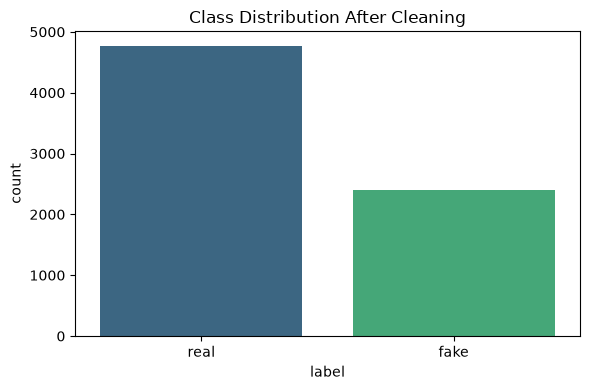

label
real    4770
fake    2398
Name: count, dtype: int64

In [126]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=clean_df,
    x="label",
    hue="label",
    palette="viridis",
    legend=False
)

plt.title("Class Distribution After Cleaning")

plt.tight_layout()

plt.show()

display(clean_df["label"].value_counts())

In [127]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    clean_df,
    test_size=0.30,
    stratify=clean_df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print(f"Train      : {len(train_df)}")
print(f"Validation : {len(val_df)}")
print(f"Test       : {len(test_df)}")

Train      : 5017
Validation : 1075
Test       : 1076


In [128]:
summary = pd.DataFrame({
    "Train": train_df["label"].value_counts(normalize=True),
    "Validation": val_df["label"].value_counts(normalize=True),
    "Test": test_df["label"].value_counts(normalize=True)
})

display(summary)

,Train,Validation,Test
label,,,
real,0.665537,0.665116,0.665428
fake,0.334463,0.334884,0.334572


In [129]:
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([

    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.85, 1.0)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )

])

val_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )

])

test_transform = val_transform

print("Transforms Created Successfully.")

Transforms Created Successfully.


In [130]:
from torch.utils.data import Dataset
from PIL import Image

CLASS_TO_IDX = {
    "fake": 0,
    "real": 1
}

IDX_TO_CLASS = {
    0: "fake",
    1: "real"
}

class CurrencyDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe.reset_index(drop=True)

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(row.image_path).convert("RGB")

        if self.transform:

            image = self.transform(image)

        label = CLASS_TO_IDX[row.label]

        return image, label

In [131]:
train_dataset = CurrencyDataset(
    train_df,
    train_transform
)

val_dataset = CurrencyDataset(
    val_df,
    val_transform
)

test_dataset = CurrencyDataset(
    test_df,
    test_transform
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

5017
1075
1076


In [132]:
from torch.utils.data import WeightedRandomSampler
import torch

labels = train_df["label"].map(CLASS_TO_IDX).values

class_counts = np.bincount(labels)

class_weights = 1.0 / class_counts

sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(
    sample_weights,
    len(sample_weights),
    replacement=True
)

print(class_counts)
print(class_weights)

[1678 3339]
[0.00059595 0.00029949]


In [133]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    sampler=sampler,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [134]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

print(criterion)

CrossEntropyLoss()


In [135]:
import torchvision.models as models
from torchvision.models import (
    MobileNet_V2_Weights,
    EfficientNet_B0_Weights,
    ResNet18_Weights
)

def build_model(model_name):

    if model_name == "mobilenet_v2":

        model = models.mobilenet_v2(
            weights=MobileNet_V2_Weights.DEFAULT
        )

        for param in model.features.parameters():
            param.requires_grad = False

        model.classifier[1] = nn.Linear(
            model.last_channel,
            2
        )

    elif model_name == "efficientnet_b0":

        model = models.efficientnet_b0(
            weights=EfficientNet_B0_Weights.DEFAULT
        )

        for param in model.features.parameters():
            param.requires_grad = False

        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            2
        )

    elif model_name == "resnet18":

        model = models.resnet18(
            weights=ResNet18_Weights.DEFAULT
        )

        for param in model.parameters():
            param.requires_grad = False

        model.fc = nn.Linear(
            model.fc.in_features,
            2
        )

    else:
        raise ValueError("Unknown model")

    return model.to(DEVICE)

In [136]:
models_to_train = [
    "mobilenet_v2",
    "efficientnet_b0",
    "resnet18"
]

for name in models_to_train:

    model = build_model(name)

    total_params = sum(p.numel() for p in model.parameters())

    trainable_params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    print("=" * 50)
    print(name)
    print(f"Total Parameters     : {total_params:,}")
    print(f"Trainable Parameters : {trainable_params:,}")

mobilenet_v2
Total Parameters     : 2,226,434
Trainable Parameters : 2,562
efficientnet_b0
Total Parameters     : 4,010,110
Trainable Parameters : 2,562
resnet18
Total Parameters     : 11,177,538
Trainable Parameters : 1,026


In [137]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.amp import GradScaler

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
EPOCHS = 15
PATIENCE = 5
MAX_GRAD_NORM = 1.0

scaler = GradScaler("cuda")

print("Training configuration initialized.")

Training configuration initialized.


In [138]:
class EarlyStopping:

    def __init__(self, patience=5):

        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.stop = False

    def __call__(self, loss):

        if loss < self.best_loss:

            self.best_loss = loss
            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:

                self.stop = True

In [139]:
from torch.amp import autocast
from tqdm.auto import tqdm

def train_one_epoch(model, loader, criterion, optimizer, scaler):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(loader, leave=False)

    for images, labels in loop:

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type="cuda"):

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            MAX_GRAD_NORM
        )

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        _, preds = outputs.max(1)

        total += labels.size(0)

        correct += preds.eq(labels).sum().item()

        loop.set_postfix(
            loss=loss.item(),
            acc=100 * correct / total
        )

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [140]:
@torch.no_grad()

def validate(model, loader, criterion):

    model.eval()

    running_loss = 0

    correct = 0

    total = 0

    for images, labels in loader:

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with autocast(device_type="cuda"):

            outputs = model(images)

            loss = criterion(outputs, labels)

        running_loss += loss.item()

        _, preds = outputs.max(1)

        total += labels.size(0)

        correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [141]:
torch.backends.cudnn.benchmark = True

In [142]:
def train_model(model_name):

    print("=" * 70)
    print(f"Training : {model_name}")
    print("=" * 70)

    model = build_model(model_name)

    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )

    early_stop = EarlyStopping(PATIENCE)

    best_acc = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(EPOCHS):

        print(f"\nEpoch {epoch+1}/{EPOCHS}")

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            scaler
        )

        val_loss, val_acc = validate(
            model,
            val_loader,
            criterion
        )

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f}"
        )

        print(
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        if val_acc > best_acc:

            best_acc = val_acc

            torch.save(
                model.state_dict(),
                MODEL_DIR / f"{model_name}.pt"
            )

        early_stop(val_loss)

        if early_stop.stop:

            print("Early stopping")

            break

    return model, history

In [143]:
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

torch.Size([64, 3, 224, 224]) torch.Size([64])


In [148]:
state = torch.load(
    MODEL_DIR / "mobilenet_v2.pt",
    map_location="cpu"
)

print(list(state.keys())[:10])

['features.0.0.weight', 'features.0.1.weight', 'features.0.1.bias', 'features.0.1.running_mean', 'features.0.1.running_var', 'features.0.1.num_batches_tracked', 'features.1.conv.0.0.weight', 'features.1.conv.0.1.weight', 'features.1.conv.0.1.bias', 'features.1.conv.0.1.running_mean']


In [144]:
mobilenet_model, mobilenet_history = train_model(
    "mobilenet_v2"
)

Training : mobilenet_v2

Epoch 1/15


  0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.6026 | Train Acc: 0.7225
Val Loss: 0.5090 | Val Acc: 0.9005

Epoch 2/15


  0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.4513 | Train Acc: 0.9011
Val Loss: 0.4118 | Val Acc: 0.9340

Epoch 3/15


...

Train Loss: 0.1775 | Train Acc: 0.9452
Val Loss: 0.1678 | Val Acc: 0.9535

Epoch 14/15


  0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.1569 | Train Acc: 0.9510
Val Loss: 0.1668 | Val Acc: 0.9591

Epoch 15/15


  0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.1577 | Train Acc: 0.9492
Val Loss: 0.1608 | Val Acc: 0.9591


In [147]:
import os

print(sorted(os.listdir(MODEL_DIR)))

['EfficientNet_B0_confusion_matrix.npy', 'EfficientNet_B0_metrics.json', 'ResNet18_confusion_matrix.npy', 'ResNet18_metrics.json', 'class_names.json', 'efficientnet_b0.pt', 'efficientnet_b0_best.pth', 'efficientnet_confusion_matrix.npy', 'efficientnet_metrics.json', 'mobilenet_v2.pt', 'mobilenetv2_confusion_matrix.npy', 'mobilenetv2_metrics.json', 'resnet18.pt', 'resnet18_best.pth']


In [149]:
import shutil

shutil.copy(
    MODEL_DIR / "mobilenet_v2.pt",
    MODEL_DIR / "mobilenetv2_best.pth"
)

print("✅ mobilenetv2_best.pth restored")

✅ mobilenetv2_best.pth restored


In [150]:
shutil.copy(
    MODEL_DIR / "mobilenet_v2.pt",
    MODEL_DIR / "currency_model_best.pth"
)

print("✅ currency_model_best.pth created")

✅ currency_model_best.pth created


In [151]:
state = torch.load(
    MODEL_DIR / "currency_model_best.pth",
    map_location="cpu"
)

print(list(state.keys())[:10])

['features.0.0.weight', 'features.0.1.weight', 'features.0.1.bias', 'features.0.1.running_mean', 'features.0.1.running_var', 'features.0.1.num_batches_tracked', 'features.1.conv.0.0.weight', 'features.1.conv.0.1.weight', 'features.1.conv.0.1.bias', 'features.1.conv.0.1.running_mean']


In [ ]:
import shutil

shutil.copy(
    MODEL_DIR / "mobilenetv2_best.pth",
    MODEL_DIR / "currency_model_best.pth"
)

print("✅ Final deployment model saved.")

In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import numpy as np

mobilenet_model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = mobilenet_model(images)

        probs = torch.softmax(outputs, dim=1)

        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

In [44]:
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_probs)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Accuracy : 0.9591
Precision: 0.9800
Recall   : 0.9581
F1 Score : 0.9689
ROC AUC  : 0.9897


In [45]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=["fake","real"]
))

              precision    recall  f1-score   support

        fake       0.92      0.96      0.94       360
        real       0.98      0.96      0.97       716

    accuracy                           0.96      1076
   macro avg       0.95      0.96      0.95      1076
weighted avg       0.96      0.96      0.96      1076



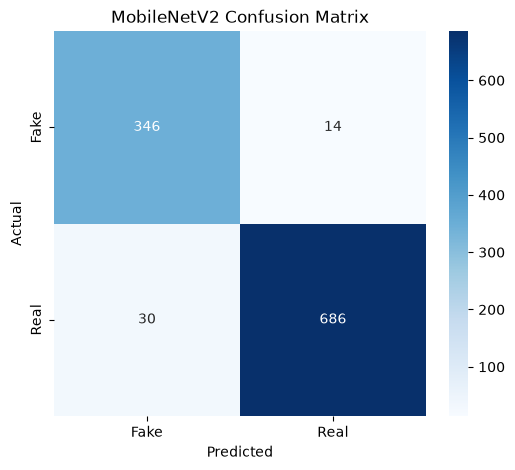

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake","Real"],
    yticklabels=["Fake","Real"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 Confusion Matrix")

plt.show()

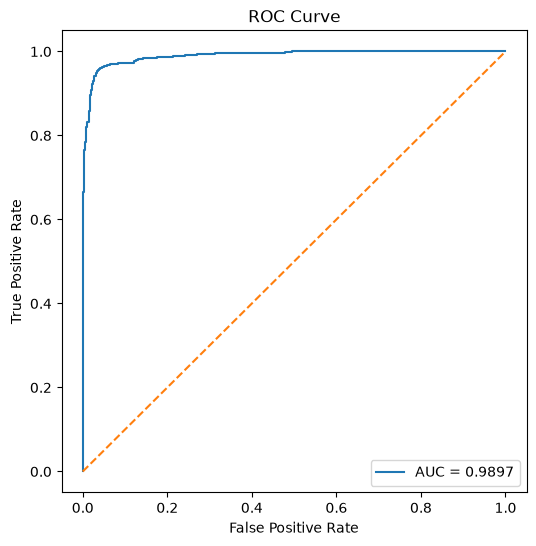

In [47]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

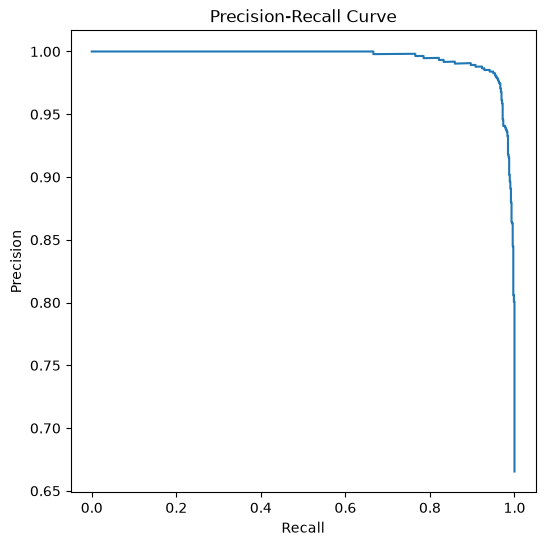

In [48]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, _ = precision_recall_curve(
    all_labels,
    all_probs
)

plt.figure(figsize=(6,6))

plt.plot(recall_curve, precision_curve)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

In [49]:
mobilenet_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]

})

mobilenet_results

,Metric,Value
0,Accuracy,0.959108
1,Precision,0.980000
2,Recall,0.958101
3,F1 Score,0.968927
4,ROC AUC,0.989657


In [56]:
%whos

Variable                  Type                     Data/Info
------------------------------------------------------------
AdamW                     type                     <class 'torch.optim.adamw.AdamW'>
BASE_DIR                  WindowsPath              c:\Users\ANKIT\Desktop\Se<...>tinelAi\datasets\currency
BATCH_SIZE                int                      64
CLASS_TO_IDX              dict                     n=2
Counter                   type                     <class 'collections.Counter'>
CurrencyDataset           type                     <class '__main__.CurrencyDataset'>
DATA_DIR                  WindowsPath              c:\Users\ANKIT\Desktop\Se<...>Ai\datasets\currency\data
DEVICE                    str                      cuda
DataLoader                type                     <class 'torch.utils.data.dataloader.DataLoader'>
Dataset                   type                     <class 'torch.utils.data.dataset.Dataset'>
EPOCHS                    int                      15

In [57]:
import torch
from pathlib import Path

SAVE_DIR = Path("../../models/currency")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

torch.save(model.state_dict(), SAVE_DIR / "mobilenetv2_best.pth")

print("✅ Model saved")

✅ Model saved


In [58]:
import json

class_names = {
    "0": "fake",
    "1": "real"
}

with open(SAVE_DIR / "class_names.json", "w") as f:
    json.dump(class_names, f, indent=4)

print("✅ Class names saved")

✅ Class names saved


In [59]:
metrics = {
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "roc_auc": float(roc_auc)
}

with open(SAVE_DIR / "mobilenetv2_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("✅ Metrics saved")

✅ Metrics saved


In [60]:
import numpy as np

np.save(SAVE_DIR / "mobilenetv2_confusion_matrix.npy", cm)

print("✅ Confusion matrix saved")

✅ Confusion matrix saved


In [61]:
import os

print(os.listdir(SAVE_DIR))

['class_names.json', 'metrics.json', 'mobilenetv2_best.pth', 'mobilenetv2_confusion_matrix.npy', 'mobilenetv2_metrics.json', 'mobilenet_v2.pt']


### ===============================
###    EfficientNet-B0 Training
### ===============================

In [70]:
efficientnet_model, efficientnet_history = train_model("efficientnet_b0")

Training : efficientnet_b0

Epoch 1/15


  0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.6041 | Train Acc: 0.6785
Val Loss: 0.4674 | Val Acc: 0.8614

Epoch 2/15


  0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.4484 | Train Acc: 0.8649
Val Loss: 0.3736 | Val Acc: 0.9079

Epoch 3/15


...

Train Loss: 0.1675 | Train Acc: 0.9482
Val Loss: 0.1736 | Val Acc: 0.9460

Epoch 14/15


  0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.1694 | Train Acc: 0.9468
Val Loss: 0.1730 | Val Acc: 0.9451

Epoch 15/15


  0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.1602 | Train Acc: 0.9464
Val Loss: 0.1679 | Val Acc: 0.9451


In [72]:
import torch

efficientnet_model.load_state_dict(
    torch.load(
        MODEL_DIR / "efficientnet_b0.pt",
        map_location=DEVICE
    )
)

efficientnet_model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [73]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

efficientnet_model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = efficientnet_model(images)

        probs = torch.softmax(outputs, dim=1)[:, 1]

        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

In [74]:
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_probs)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")

Accuracy  : 0.9554
Precision : 0.9855
Recall    : 0.9469
F1 Score  : 0.9658
ROC AUC   : 0.9912


In [75]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["fake", "real"]
    )
)

              precision    recall  f1-score   support

        fake       0.90      0.97      0.94       360
        real       0.99      0.95      0.97       716

    accuracy                           0.96      1076
   macro avg       0.94      0.96      0.95      1076
weighted avg       0.96      0.96      0.96      1076



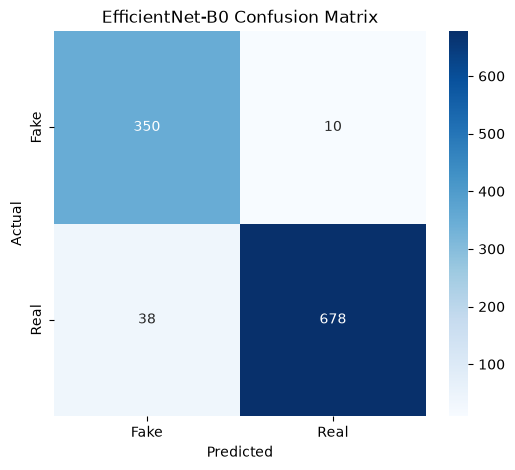

In [76]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake","Real"],
    yticklabels=["Fake","Real"]
)

plt.title("EfficientNet-B0 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [77]:
import json

metrics = {
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "roc_auc": float(roc_auc)
}

with open(MODEL_DIR / "efficientnet_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

In [78]:
import numpy as np

np.save(
    MODEL_DIR / "efficientnet_confusion_matrix.npy",
    cm
)

In [79]:
import torch

torch.save(
    efficientnet_model.state_dict(),
    MODEL_DIR / "efficientnet_b0_best.pth"
)

print("✅ EfficientNet-B0 model saved successfully.")

✅ EfficientNet-B0 model saved successfully.


In [80]:
import gc
import torch

del efficientnet_model

gc.collect()
torch.cuda.empty_cache()

print(torch.cuda.memory_allocated() / 1024**2, "MB")

87.60498046875 MB


In [81]:
print("=" * 50)
print("ResNet18 Training")
print("=" * 50)

resnet18_model, resnet18_history = train_model("resnet18")

ResNet18 Training
Training : resnet18

Epoch 1/15


  0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.7028 | Train Acc: 0.5382
Val Loss: 0.6349 | Val Acc: 0.6316

Epoch 2/15


  0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.5451 | Train Acc: 0.7459
Val Loss: 0.4993 | Val Acc: 0.7898

Epoch 3/15


...

Train Loss: 0.2403 | Train Acc: 0.9163
Val Loss: 0.2277 | Val Acc: 0.9181

Epoch 14/15


  0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.2176 | Train Acc: 0.9268
Val Loss: 0.2151 | Val Acc: 0.9209

Epoch 15/15


  0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.2251 | Train Acc: 0.9201
Val Loss: 0.2063 | Val Acc: 0.9265


In [84]:
torch.save(
    resnet18_model.state_dict(),
    MODEL_DIR / "resnet18_best.pth"
)

print("✅ ResNet18 saved successfully")

✅ ResNet18 saved successfully


In [87]:
import torch

state = torch.load(
    MODEL_DIR / "mobilenetv2_best.pth",
    map_location="cpu"
)

print(list(state.keys())[:20])

['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight']


In [88]:
state = torch.load(
    MODEL_DIR / "efficientnet_b0_best.pth",
    map_location="cpu"
)

print(list(state.keys())[:20])

['features.0.0.weight', 'features.0.1.weight', 'features.0.1.bias', 'features.0.1.running_mean', 'features.0.1.running_var', 'features.0.1.num_batches_tracked', 'features.1.0.block.0.0.weight', 'features.1.0.block.0.1.weight', 'features.1.0.block.0.1.bias', 'features.1.0.block.0.1.running_mean', 'features.1.0.block.0.1.running_var', 'features.1.0.block.0.1.num_batches_tracked', 'features.1.0.block.1.fc1.weight', 'features.1.0.block.1.fc1.bias', 'features.1.0.block.1.fc2.weight', 'features.1.0.block.1.fc2.bias', 'features.1.0.block.2.0.weight', 'features.1.0.block.2.1.weight', 'features.1.0.block.2.1.bias', 'features.1.0.block.2.1.running_mean']


In [89]:
state = torch.load(
    MODEL_DIR / "resnet18_best.pth",
    map_location="cpu"
)

print(list(state.keys())[:20])

['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight']


In [90]:
state = torch.load(
    MODEL_DIR / "mobilenet_v2.pt",
    map_location="cpu"
)

print(list(state.keys())[:20])

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\ANKIT\\Desktop\\SentinelAi\\models\\currency\\mobilenet_v2.pt'

In [91]:
import os

for f in sorted(os.listdir(MODEL_DIR)):
    print(f)

class_names.json
efficientnet_b0.pt
efficientnet_b0_best.pth
efficientnet_confusion_matrix.npy
efficientnet_metrics.json
mobilenetv2_best.pth
mobilenetv2_confusion_matrix.npy
mobilenetv2_metrics.json
resnet18.pt
resnet18_best.pth


In [92]:
state = torch.load(
    MODEL_DIR / "efficientnet_b0.pt",
    map_location="cpu"
)

print(type(state))

if isinstance(state, dict):
    print(list(state.keys())[:20])

<class 'collections.OrderedDict'>
['features.0.0.weight', 'features.0.1.weight', 'features.0.1.bias', 'features.0.1.running_mean', 'features.0.1.running_var', 'features.0.1.num_batches_tracked', 'features.1.0.block.0.0.weight', 'features.1.0.block.0.1.weight', 'features.1.0.block.0.1.bias', 'features.1.0.block.0.1.running_mean', 'features.1.0.block.0.1.running_var', 'features.1.0.block.0.1.num_batches_tracked', 'features.1.0.block.1.fc1.weight', 'features.1.0.block.1.fc1.bias', 'features.1.0.block.1.fc2.weight', 'features.1.0.block.1.fc2.bias', 'features.1.0.block.2.0.weight', 'features.1.0.block.2.1.weight', 'features.1.0.block.2.1.bias', 'features.1.0.block.2.1.running_mean']


In [93]:
state = torch.load(
    MODEL_DIR / "resnet18.pt",
    map_location="cpu"
)

print(type(state))

if isinstance(state, dict):
    print(list(state.keys())[:20])

<class 'collections.OrderedDict'>
['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight']


In [94]:
import json

with open(MODEL_DIR / "mobilenetv2_metrics.json", "r") as f:
    mobile_metrics = json.load(f)

print(mobile_metrics)

{'accuracy': 0.9591078066914498, 'precision': 0.98, 'recall': 0.9581005586592178, 'f1_score': 0.9689265536723164, 'roc_auc': 0.9896570453134699}



========== ResNet18 ==========
Accuracy : 0.9359
Precision: 0.9695
Recall   : 0.9330
F1 Score : 0.9509
ROC AUC  : 0.9842

Classification Report

              precision    recall  f1-score   support

        fake       0.88      0.94      0.91       360
        real       0.97      0.93      0.95       716

    accuracy                           0.94      1076
   macro avg       0.92      0.94      0.93      1076
weighted avg       0.94      0.94      0.94      1076



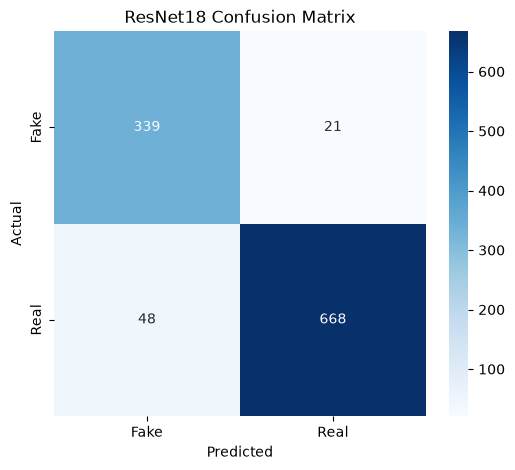

In [95]:
resnet = models.resnet18(weights=None)

resnet.fc = nn.Linear(
    resnet.fc.in_features,
    2
)

resnet.load_state_dict(
    torch.load(
        MODEL_DIR / "resnet18_best.pth",
        map_location=DEVICE
    )
)

resnet.to(DEVICE)
resnet.eval()

resnet_metrics = evaluate_model(
    resnet,
    "ResNet18"
)


========== EfficientNet_B0 ==========
Accuracy : 0.9554
Precision: 0.9855
Recall   : 0.9469
F1 Score : 0.9658
ROC AUC  : 0.9912

Classification Report

              precision    recall  f1-score   support

        fake       0.90      0.97      0.94       360
        real       0.99      0.95      0.97       716

    accuracy                           0.96      1076
   macro avg       0.94      0.96      0.95      1076
weighted avg       0.96      0.96      0.96      1076



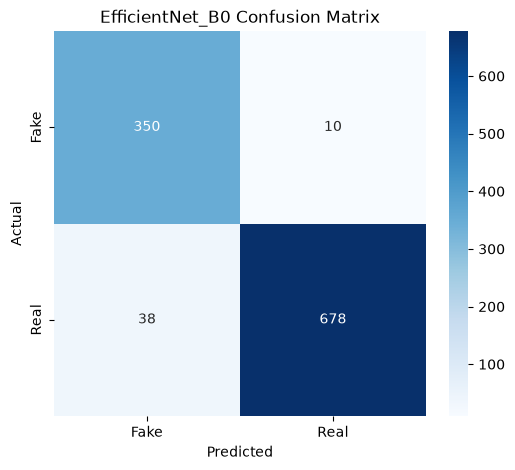

In [96]:
efficientnet = models.efficientnet_b0(weights=None)

efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features,
    2
)

efficientnet.load_state_dict(
    torch.load(
        MODEL_DIR / "efficientnet_b0_best.pth",
        map_location=DEVICE
    )
)

efficientnet.to(DEVICE)
efficientnet.eval()

efficient_metrics = evaluate_model(
    efficientnet,
    "EfficientNet_B0"
)

In [97]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "Model": "MobileNetV2",
        **mobile_metrics
    },
    {
        "Model": "EfficientNet-B0",
        **efficient_metrics
    },
    {
        "Model": "ResNet18",
        **resnet_metrics
    }
])

comparison = comparison.sort_values(
    by=["f1", "roc_auc", "accuracy"],
    ascending=False
)

comparison.reset_index(drop=True, inplace=True)

comparison

,Model,accuracy,precision,recall,f1_score,roc_auc,f1
0,EfficientNet-B0,0.955390,0.985465,0.946927,NaN,0.991236,0.965812
1,ResNet18,0.935874,0.969521,0.932961,NaN,0.984164,0.950890
2,MobileNetV2,0.959108,0.980000,0.958101,0.968927,0.989657,NaN


In [98]:
import shutil

shutil.copy(
    MODEL_DIR / "mobilenetv2_best.pth",
    MODEL_DIR / "currency_model_best.pth"
)

WindowsPath('c:/Users/ANKIT/Desktop/SentinelAi/models/currency/currency_model_best.pth')

In [101]:
import torch

state = torch.load(
    MODEL_DIR / "currency_model_best.pth",
    map_location="cpu"
)

print(list(state.keys())[:10])

['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean']


In [102]:
state = torch.load(
    MODEL_DIR / "mobilenetv2_best.pth",
    map_location="cpu"
)

print(list(state.keys())[:10])

['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean']
